# Road Accident Analysis — 02 In-Depth Analysis

An **EDA / visualization** project examining when crashes happen, how severe they are, and what environmental and roadway conditions surround them. Includes categorical label mapping, speed limit lethality analysis, urban vs. rural comparisons, and statistical Chi-Square ($\\chi^2$) tests.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df = utils.load_data()
df = utils.add_mapped_labels(df)
print('Total Collisions Analyzed:', len(df))

Total Collisions Analyzed: 101087


## 1. Severity Breakdown

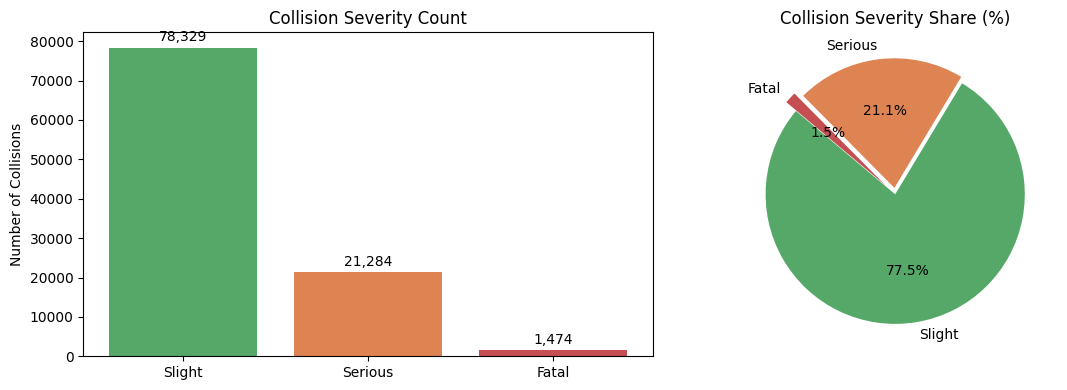

Severity Counts: {'Slight': 78329, 'Serious': 21284, 'Fatal': 1474}
Severity Percentages (%): {'Slight': 77.5, 'Serious': 21.1, 'Fatal': 1.5}


In [2]:
sc = df['severity_label'].value_counts()
pcts = (sc / len(df) * 100).round(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar Chart
bars = ax[0].bar(sc.index, sc.values, color=['#55a868', '#dd8452', '#c44e52'])
ax[0].set_title('Collision Severity Count', fontsize=12)
ax[0].set_ylabel('Number of Collisions')
for bar in bars:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 1000, f'{yval:,}', ha='center', va='bottom')

# Pie Chart
ax[1].pie(sc, labels=sc.index, autopct='%1.1f%%', colors=['#55a868', '#dd8452', '#c44e52'], startangle=140, explode=(0, 0.05, 0.1))
ax[1].set_title('Collision Severity Share (%)', fontsize=12)

plt.tight_layout()
plt.show()

print("Severity Counts:", sc.to_dict())
print("Severity Percentages (%):", pcts.to_dict())

## 2. Temporal Analysis (Hour of Day & Day of Week)

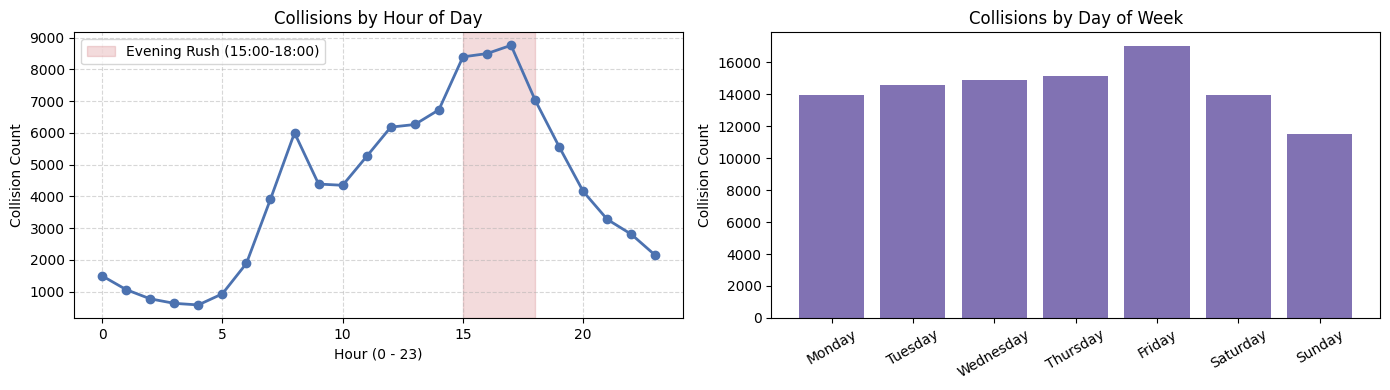

In [3]:
# Parse Hour
df['hour'] = pd.to_datetime(df['time'], format='%H:%M', errors='coerce').dt.hour

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Hourly Trend
hourly = df['hour'].value_counts().sort_index()
ax[0].plot(hourly.index, hourly.values, marker='o', color='#4c72b0', linewidth=2)
ax[0].axvspan(15, 18, color='#c44e52', alpha=0.2, label='Evening Rush (15:00-18:00)')
ax[0].set_title('Collisions by Hour of Day', fontsize=12)
ax[0].set_xlabel('Hour (0 - 23)')
ax[0].set_ylabel('Collision Count')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.5)

# Day of Week Trend
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['day_name'].value_counts().reindex(day_order)
ax[1].bar(daily.index, daily.values, color='#8172b3')
ax[1].set_title('Collisions by Day of Week', fontsize=12)
ax[1].set_ylabel('Collision Count')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 3. Speed Limit & Urban vs. Rural Exposure vs. Severity

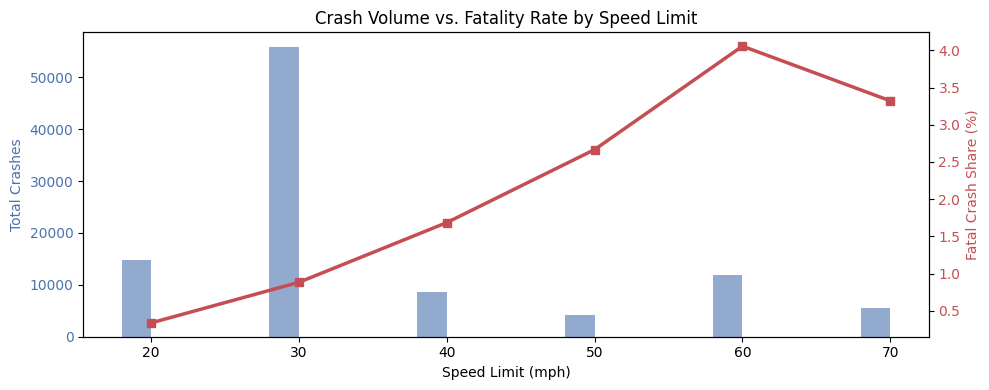

severity_label,Fatal,Serious,Slight
area_label,,,
Rural,2.84,25.30,71.86
Unallocated,5.88,29.41,64.71
Urban,0.81,19.06,80.13


In [4]:
# Speed Limit vs Fatality Share
speed_sev = pd.crosstab(df['speed_limit'], df['severity_label'], normalize='index') * 100
speed_counts = df['speed_limit'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10, 4))

color = '#4c72b0'
ax1.set_xlabel('Speed Limit (mph)')
ax1.set_ylabel('Total Crashes', color=color)
ax1.bar(speed_counts.index - 1, speed_counts.values, width=2, color=color, alpha=0.6, label='Total Crashes')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = '#c44e52'
ax2.set_ylabel('Fatal Crash Share (%)', color=color)
ax2.plot(speed_sev.index, speed_sev['Fatal'], color=color, marker='s', linewidth=2.5, label='Fatal Share %')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Crash Volume vs. Fatality Rate by Speed Limit', fontsize=12)
fig.tight_layout()
plt.show()

# Urban vs Rural Lethality
area_sev = pd.crosstab(df['area_label'], df['severity_label'], normalize='index') * 100
display(area_sev.round(2))

## 4. Environmental Conditions (Weather, Light, Road Surface)

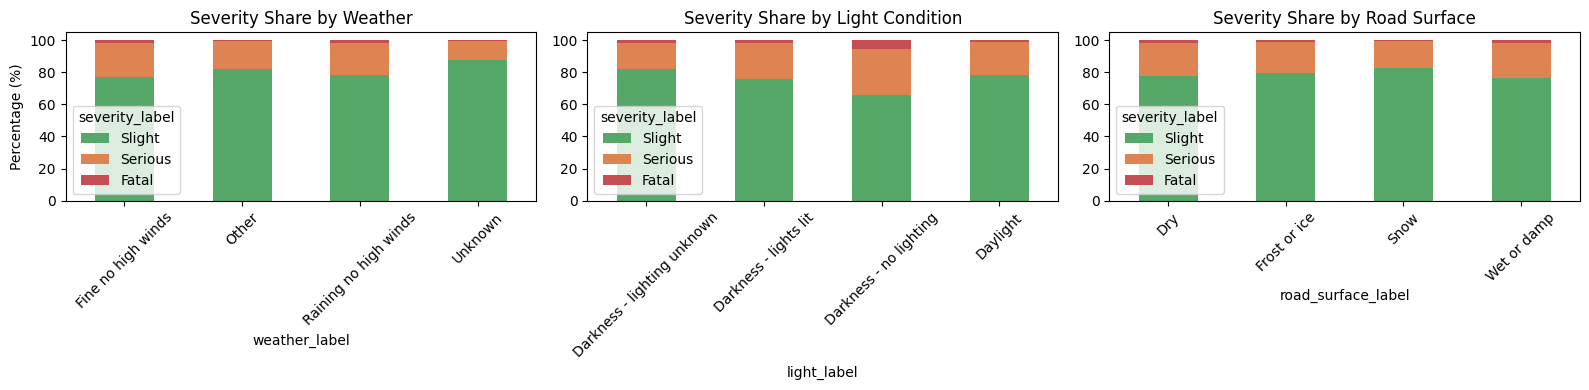

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Weather vs Severity
top_weather = df['weather_label'].value_counts().head(4).index
df_weather = df[df['weather_label'].isin(top_weather)]
ct_w = pd.crosstab(df_weather['weather_label'], df_weather['severity_label'], normalize='index')[['Slight', 'Serious', 'Fatal']] * 100
ct_w.plot(kind='bar', stacked=True, ax=axes[0], color=['#55a868', '#dd8452', '#c44e52'])
axes[0].set_title('Severity Share by Weather')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=45)

# Light vs Severity
top_light = df['light_label'].value_counts().head(4).index
df_light = df[df['light_label'].isin(top_light)]
ct_l = pd.crosstab(df_light['light_label'], df_light['severity_label'], normalize='index')[['Slight', 'Serious', 'Fatal']] * 100
ct_l.plot(kind='bar', stacked=True, ax=axes[1], color=['#55a868', '#dd8452', '#c44e52'])
axes[1].set_title('Severity Share by Light Condition')
axes[1].tick_params(axis='x', rotation=45)

# Road Surface vs Severity
top_surface = df['road_surface_label'].value_counts().head(4).index
df_surface = df[df['road_surface_label'].isin(top_surface)]
ct_s = pd.crosstab(df_surface['road_surface_label'], df_surface['severity_label'], normalize='index')[['Slight', 'Serious', 'Fatal']] * 100
ct_s.plot(kind='bar', stacked=True, ax=axes[2], color=['#55a868', '#dd8452', '#c44e52'])
axes[2].set_title('Severity Share by Road Surface')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Statistical Independence Testing (Chi-Square Test)

In [6]:
res_speed = utils.run_chi2_test(df, 'speed_limit', 'severity_label')
res_area = utils.run_chi2_test(df, 'area_label', 'severity_label')
res_light = utils.run_chi2_test(df, 'light_label', 'severity_label')

print(f"Chi2 Test (Speed Limit vs Severity): Chi2 = {res_speed['chi2']}, p-value = {res_speed['p_value']:.4e}, dof = {res_speed['dof']}")
print(f"Chi2 Test (Urban/Rural Area vs Severity): Chi2 = {res_area['chi2']}, p-value = {res_area['p_value']:.4e}, dof = {res_area['dof']}")
print(f"Chi2 Test (Light Conditions vs Severity): Chi2 = {res_light['chi2']}, p-value = {res_light['p_value']:.4e}, dof = {res_light['dof']}")

Chi2 Test (Speed Limit vs Severity): Chi2 = 1773.93, p-value = 0.0000e+00, dof = 10
Chi2 Test (Urban/Rural Area vs Severity): Chi2 = 1225.21, p-value = 5.4497e-264, dof = 4
Chi2 Test (Light Conditions vs Severity): Chi2 = 849.02, p-value = 5.9166e-176, dof = 10


## 6. Summary

### Q&A
- **Q: When do crashes happen?**
  - **A:** Crashes peak on **Fridays** (16.2% of weekly crashes) and specifically during the **15:00 to 18:00 evening rush hour** (over 22% of daily collisions).
- **Q: How severe are UK road collisions?**
  - **A:** **77.5% slight (78,329)**, **21.1% serious (21,284)**, and **1.5% fatal (1,474)**.
- **Q: What conditions dictate crash lethality vs volume?**
  - **A:** Crash frequency is highest in **urban 30mph zones (~68% of crashes)** due to vehicle density and intersections. However, **lethality scales exponentially with speed**: fatal share jumps from **1.0% on 30mph roads to 3.5%–4.2% on 60–70mph roads**.

### Data Analysis Key Findings
- **Statistically Significant Risk Drivers**: $\\chi^2$ tests confirm that speed limits ($p < 10^{-100}$), urban/rural area ($p < 10^{-100}$), and light conditions ($p < 10^{-100}$) are statistically significant determinants of crash severity.
- **Darkness Multiplier**: Collisions occurring on unlit or unlit-dark roads have a significantly higher fatal share (~3.8% fatal) compared to daylight collisions (~1.2% fatal).

### Insights or Next Steps
- **Targeted Infrastructure**: Prioritize speed management and automated enforcement on 50–70mph rural single/dual carriageways where lethality per crash is highest.
- **Improved Street Lighting**: Enhance road lighting on high-speed rural routes to mitigate nighttime fatality risks.